In [1]:
import os

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
with open("C:/Users/gorab/.cache/kagglehub/datasets/fhnw-i4ds/sdobenchmark/versions/4/SDOBenchmark_example/README.txt", "r") as f:
    print(f.read())

Noisy images

Some raw data from the satellite is flagged as noisy, e.g. because of a moon eclipse or because of a recalibration. The images were still created, yet they have a string "flagged" in the ImageDescription metadata (EXIF).


File Structure

The folder layout is irrelevant for training, because each sample's id in 'meta_data.csv' maps to a sample.
See e.g. https://github.com/i4ds/SDOBenchmark/blob/master/notebooks/utils/keras_generator.py#L61
Except if you want to split the training set further, e.g. for cross validation: Make the splitting on the first layer of folders ('11402', '13386', ...).

If you still want to know more:
The folders "test" and "training" contain folders with numbers like '11402' or '13386'. Those numbers are Active Region numbers, i.e. enumarations for patches of the sun where we take samples from.
Within those folders are the sample folders. Each sample folder's name is a combination of a date and a number, e.g. '2014_01_28_12_50_00_1'. The date defin

In [4]:
from pathlib import Path

base = Path(r"C:/Users/gorab/.cache/kagglehub/datasets/fhnw-i4ds/sdobenchmark/versions/4")

example_path = base / "SDOBenchmark_full"

train_path = example_path / "training"
test_path = example_path / "test"

In [5]:
num_dirs = sum(
    1 for name in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, name))
)

print("Top-level directories:", num_dirs)

Top-level directories: 1091


In [20]:
import pandas as pd
import os
import numpy as np

meta_path = os.path.join(train_path, "meta_data.csv")
flare_df = pd.read_csv(meta_path, parse_dates=["start", "end"], index_col="id")

meta_path2 = os.path.join(test_path, "meta_data.csv")
flare_df2 = pd.read_csv(meta_path2, parse_dates=["start", "end"], index_col="id")

flare_df

,start,end,peak_flux
id,,,
11390_2012_01_05_17_06_01_0,2012-01-05 05:06:01,2012-01-05 17:06:01,8.000000e-07
11390_2012_01_05_17_19_01_0,2012-01-05 05:19:01,2012-01-05 17:19:01,1.647059e-06
11390_2012_01_05_17_19_01_1,2012-01-06 05:19:00,2012-01-06 17:19:00,1.647059e-06
11390_2012_01_06_17_20_58_0,2012-01-06 05:20:58,2012-01-06 17:20:58,1.164706e-06
11390_2012_01_04_07_22_01_0,2012-01-03 19:22:01,2012-01-04 07:22:01,2.235294e-06
...,...,...,...
12692_2017_12_22_06_29_01_0,2017-12-21 18:29:01,2017-12-22 06:29:01,3.882353e-07
12692_2017_12_23_06_30_50_0,2017-12-22 18:30:50,2017-12-23 06:30:50,1.176471e-07
12692_2017_12_23_06_30_50_1,2017-12-23 08:36:00,2017-12-23 20:36:00,1.176471e-07


In [334]:
from torch.utils.data import Dataset

def flux_to_class(f):
    if f < 1e-7:
        return "quiet"
    elif f < 1e-6:
        return "B"
    elif f < 1e-5:
        return "C"
    elif f < 1e-4:
        return "M"
    else:
        return "X"

# Dataset loader datastructure
class SolarDataset(Dataset):
    def __init__(self, df, root, transform=None, mode="sequence", max_samples = 500):
        self.df = df
        self.root = root
        self.transform = transform
        self.mode = mode
        self.max_samples = max_samples
        self.class_map = {"quiet": 0, "B": 1, "C": 2, "M": 3, "X": 4}

        self.valid_indices = []

        # for all the data
        for i in range(len(df)):

            # get the row and sample id
            row = df.iloc[i]
            sample_id = row.name

            try:
                # get region and sample folders from df, 
                region, sample_folder = sample_id.split("_", 1)
                sample_path = os.path.join(root, region, sample_folder)

                # get images
                files = os.listdir(sample_path)

                # get magnetrogram images only for the time being
                mags = [f for f in files if "magnetogram" in f]

                # keep only 4-frame samples
                if len(mags) == 4:
                    self.valid_indices.append(i)

                    if self.max_samples and len(self.valid_indices) >= self.max_samples:
                        break


            except:
                continue

    def __len__(self):
        return len(self.valid_indices)

    # return images, 
    def __getitem__(self, idx):
        row = self.df.iloc[self.valid_indices[idx]]
        sample_id = row.name
        target = row["peak_flux"]
        cls = flux_to_class(target)
        cls_id = self.class_map[cls]
        region, sample_folder = sample_id.split("_", 1)
        sample_path = os.path.join(self.root, region, sample_folder)

        files = sorted(os.listdir(sample_path))
        mags = [f for f in files if "magnetogram" in f]

        imgs = []
        for f in mags:
            img = Image.open(os.path.join(sample_path, f)).convert("L")

            if self.transform:
                img = self.transform(img)

            imgs.append(img)
        if self.mode == "single":
            img = imgs[-1]  # baseline
            return img, torch.tensor(target, dtype=torch.float32), torch.tensor(cls_id)    
        elif self.mode == "sequence":
            imgs = torch.stack(imgs)
            return imgs, torch.tensor(target, dtype=torch.float32), torch.tensor(cls_id)
        else:
            raise ValueError("mode must be 'single' or 'sequence'")

In [345]:
from torchvision import transforms

# PIL image -> tensor. Needed for CNN, and torch. 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_sequence = SolarDataset(flare_df, train_path, transform, "sequence", max_samples=1000)
print("Dataset size:", len(train_sequence))

test_sequence = SolarDataset(flare_df2, test_path, transform, "sequence", max_samples=1000)
print("Dataset size:", len(test_sequence))

train_single = SolarDataset(flare_df, train_path, transform, "single", max_samples=1000)
print("Dataset size:", len(train_single))

test_single = SolarDataset(flare_df2, test_path, transform, "single", max_samples=1000)
print("Dataset size:", len(test_single))

Dataset size: 1000
Dataset size: 830
Dataset size: 1000
Dataset size: 830


In [346]:
import matplotlib.pyplot as plt
import torch

# reverse mapping for readability
CLASS_NAMES = {0: "quiet", 1: "B", 2: "C", 3: "M", 4: "X"}

def show_sample(dataset, idx):
    sample = dataset[idx]

    # handle both cases (with or without class)
    if len(sample) == 3:
        x, y, cls_id = sample
        cls_name = CLASS_NAMES[int(cls_id)]
    else:
        x, y = sample
        cls_name = "N/A"

    # --- SEQUENCE CASE ---
    if x.dim() == 4:  # [T, C, H, W]
        T = x.shape[0]
        fig, axes = plt.subplots(1, T, figsize=(3*T, 3))

        if T == 1:
            axes = [axes]

        for i in range(T):
            axes[i].imshow(x[i].squeeze(), cmap="gray")
            axes[i].set_title(f"t{i+1}")
            axes[i].axis("off")

    # --- SINGLE IMAGE CASE ---
    elif x.dim() == 3:  # [C, H, W]
        fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        ax.imshow(x.squeeze(), cmap="gray")
        ax.set_title("single frame")
        ax.axis("off")

    else:
        raise ValueError("Unexpected input shape")

    # title with both regression + class
    plt.suptitle(
        f"peak_flux = {y.item():.2e} | class = {cls_name}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

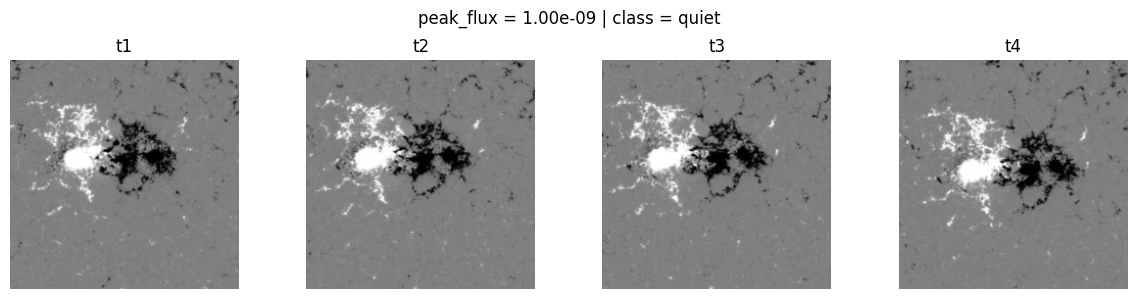

In [347]:
import random
idx = random.randint(0, len(train_sequence)-1)
show_sample(train_sequence, idx)

In [394]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 in channel, 16 out, 3 x 3 kernel size, padding
        self.conv1 = nn.Conv2d(1, 16, 3, padding=0)
        # second later, 16 in, 32 out, 3 x3 kernel size, padding
        self.conv2 = nn.Conv2d(16, 32, 3, padding=0)
        # down sampling 224 -> 112 -> 56
        # keeps strongest features, reduces computation
        self.pool = nn.MaxPool2d(2)
        # adaptive average pooling, forces output feature map to be exactly 8x8
        # output size depends on input resolution, fully connected layer would break
        # basically, model adapts to image size so stuff doesn't break
        self.adapt = nn.AdaptiveAvgPool2d((8, 8))
        # fully connected layer : 32 channels * 8 x 8 (fully flatten feature map)
        # maps it to 64 dimensional vector
        # spatial feature -> abstract representation
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        # maps 64 features to single scalar, the predicted peak_flux
        self.fc2 = nn.Linear(64, 1)
    def forward_features(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.adapt(x)
        x = x.view(x.size(0), -1)
        return x
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.adapt(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x[:, 0]

In [401]:
from torch.utils.data import random_split
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import Subset

# extract only VALID dataset samples
sample_ids = [train_single.df.index[i] for i in train_single.valid_indices]

# get active region ids
groups = np.array([s.split("_")[0] for s in sample_ids])

# dataset indices (aligned)
indices = np.arange(len(train_single))

# group-aware split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
train_idx, val_idx = next(gss.split(indices, groups=groups))

# subsets
train_ds = Subset(train_single, train_idx)
val_ds2 = Subset(train_single, val_idx)

# data loaders for both training and validation sets
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds2, batch_size=16, shuffle=False)

# use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# make model with L1 loss function (MAE)
model = BaselineCNN().to(device)
loss_fn = nn.L1Loss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# train in epochs
epochs = 15
for epoch in range(epochs):
    # training
    model.train()
    # accumulate loss
    train_loss = 0
    # for input images and labels
    for x, y, z in train_loader:
        # move data to device
        x = x.to(device).float()
        y = y.to(device).float()
        # reset gradients - torch accumulates and stacks gradients by defualt
        # clears old gradients in between batches
        optimizer.zero_grad()
        # forward pass, we get predictions
        preds = model(x)
        # compute loss 
        loss = loss_fn(preds, y)
        # backward propagation (computes gradients of loss for all model parameters)
        # learning signal
        loss.backward()
        # update weights/model params using gradients
        optimizer.step()
        # acc loss
        train_loss += loss.item()
    # average loss
    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, z in val_loader:
            # move data to device
            x = x.to(device).float()
            y = y.to(device).float()
            # prediciton
            preds = model(x)
            # loss 
            loss = loss_fn(preds, y)
            # acc loss
            val_loss += loss.item()
    # average validation los
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/15 | Train Loss: 0.011073 | Val Loss: 0.001717
Epoch 2/15 | Train Loss: 0.000890 | Val Loss: 0.001544
Epoch 3/15 | Train Loss: 0.000745 | Val Loss: 0.001452
Epoch 4/15 | Train Loss: 0.000963 | Val Loss: 0.000585
Epoch 5/15 | Train Loss: 0.000552 | Val Loss: 0.001199
Epoch 6/15 | Train Loss: 0.000536 | Val Loss: 0.000553
Epoch 7/15 | Train Loss: 0.001297 | Val Loss: 0.000831
Epoch 8/15 | Train Loss: 0.000856 | Val Loss: 0.001860
Epoch 9/15 | Train Loss: 0.001156 | Val Loss: 0.000985
Epoch 10/15 | Train Loss: 0.000692 | Val Loss: 0.001415
Epoch 11/15 | Train Loss: 0.000526 | Val Loss: 0.000417
Epoch 12/15 | Train Loss: 0.000328 | Val Loss: 0.000806
Epoch 13/15 | Train Loss: 0.000581 | Val Loss: 0.001000
Epoch 14/15 | Train Loss: 0.000924 | Val Loss: 0.001012
Epoch 15/15 | Train Loss: 0.000521 | Val Loss: 0.000516


In [404]:
# freeze model
model.eval()
torch.save(model.state_dict(), "baseline.pth")

In [405]:
# testing
test_loader = DataLoader(test_single, batch_size=16, shuffle=False)
test_loss = 0
model.eval()
with torch.no_grad():
    for x, y, z in test_loader:
        x = x.to(device).float()
        y = y.to(device).float()

        preds = model(x)
        loss = loss_fn(preds, y)

        test_loss += loss.item()

test_loss /= len(test_loader)

print("Final Test Loss:", test_loss)

Final Test Loss: 0.0004925421772685905


Some notes. CNN + LSTM would not be a good idea because my sequences are only 4 frames long at the max. CNN + temporal attention is better. It learns the imporance of every step, answering what time matters the most. We also have parrallel computation, simpler + fewer parameters + highly interpretable. Problems: it does not remember the sequence, it treats frames more like a set, unless you add position encoding, might miss subtle dynamics if evolution pattern matters deeply. 

So lets try this:

In [406]:
# imput: B (batch size), T (number of frames), F (number of features)
class TemporalAttention(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.attn = nn.Linear(feature_dim, 1)
    def forward(self, x):
        # x: [B, T, F]
        # compute attention scores
        weights = self.attn(x)  
        # normalize with softmax, weights sum to 1 accross time     
        weights = torch.softmax(weights, dim=1)
        # weighted sum - temporal aggregation. 
        out = (x * weights).sum(dim=1)  # weighted sum
        return out, weights

# 4 images -> CNN -> 4 feature vectors -> attention -> weighted combination -> prediction
class AttentionTemporalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # use frame CNN to encode frames
        self.encoder = BaselineCNN()
        # use temporal attention
        self.attention = TemporalAttention(32 * 8 * 8)
        self.head = nn.Sequential(
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        features = []
        # loop over time
        for t in range(T):
            f = self.encoder(x[:, t])
            features.append(f)
        # stack features
        features = torch.stack(features, dim=1)  # [B, T, F]
        # apply attention
        fused, attn_weights = self.attention(features)
        # final prediciton, safer squeeze
        out = self.head(fused).squeeze()
        return out, attn_weights

In [410]:
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import Subset

# extract only VALID dataset samples
sample_ids = [train_sequence.df.index[i] for i in train_sequence.valid_indices]

# get active region ids
groups = np.array([s.split("_")[0] for s in sample_ids])

# dataset indices (aligned)
indices = np.arange(len(train_sequence))

# group-aware split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
train_idx, val_idx = next(gss.split(indices, groups=groups))

# subsets
train_ds = Subset(train_sequence, train_idx)
val_ds = Subset(train_sequence, val_idx)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

epochs = 10
# use baseline cnn as shared encoder inside temporal model
encoder = BaselineCNN().to(device)

class AttentionTemporalCNN(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.attention = TemporalAttention(2048)
        self.head = nn.Sequential(
            nn.Linear(2048, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        features = []
        for t in range(T):
            f = self.encoder.forward_features(x[:, t])
            features.append(f)
        features = torch.stack(features, dim=1)  # [B, T, 2048]
        fused, attn = self.attention(features)
        out = self.head(fused).squeeze()
        return out, attn


model = AttentionTemporalCNN(encoder).to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):

    # training
    model.train()
    train_loss = 0

    for x, y , z in train_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()

        optimizer.zero_grad()

        preds, attn = model(x)     # unpack outputs
        loss = loss_fn(preds, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, z in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()

            preds, attn = model(x)
            loss = loss_fn(preds, y)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

Epoch 1/10 | Train: 0.017815 | Val: 0.001761
Epoch 2/10 | Train: 0.003169 | Val: 0.003452
Epoch 3/10 | Train: 0.003279 | Val: 0.002442
Epoch 4/10 | Train: 0.003302 | Val: 0.001155
Epoch 5/10 | Train: 0.002734 | Val: 0.001243
Epoch 6/10 | Train: 0.003678 | Val: 0.004140
Epoch 7/10 | Train: 0.002353 | Val: 0.004032
Epoch 8/10 | Train: 0.001887 | Val: 0.003336
Epoch 9/10 | Train: 0.001890 | Val: 0.002095
Epoch 10/10 | Train: 0.002073 | Val: 0.000375


In [411]:
model.eval()
torch.save(model.state_dict(), "attention.pth")

In [412]:
test_loss = 0
test_loader = DataLoader(test_sequence, batch_size=8, shuffle=True)
all_preds = []
all_targets = []
all_attn = []

with torch.no_grad():
    for x, y, z in test_loader:
        x = x.to(device).float()
        y = y.to(device).float()

        preds, attn = model(x)
        loss = loss_fn(preds, y)
        test_loss += loss.item()

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())
        all_attn.append(attn.cpu())

test_loss /= len(test_loader)

print(f"Final Test Loss: {test_loss:.6f}")

all_attn = torch.cat(all_attn, dim=0)   # [N, 4, 1]
mean_attn = all_attn.mean(dim=0).squeeze()  # [4]
print(mean_attn)

Final Test Loss: 0.000372
tensor([0.2500, 0.2500, 0.2500, 0.2500])


In [463]:
all_attn

tensor([[[0.2501],
         [0.2500],
         [0.2500],
         [0.2500]],

        [[0.2498],
         [0.2499],
         [0.2501],
         [0.2501]],

        [[0.2500],
         [0.2499],
         [0.2500],
         [0.2500]],

        ...,

        [[0.2497],
         [0.2499],
         [0.2502],
         [0.2502]],

        [[0.2497],
         [0.2500],
         [0.2502],
         [0.2502]],

        [[0.2501],
         [0.2500],
         [0.2500],
         [0.2500]]])

In [414]:
baseline_model = BaselineCNN().to(device)
baseline_model.load_state_dict(torch.load("baseline.pth"))

<All keys matched successfully>

In [415]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.eval()

        output = self.model(x)

        # if model returns tuple (pred, attn)
        if isinstance(output, tuple):
            output = output[0]

        self.model.zero_grad()
        output.backward(torch.ones_like(output))

        grads = self.gradients           # [B, C, H, W]
        acts = self.activations          # [B, C, H, W]

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)

        # cam = F.relu(cam)

        # normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        print(self.gradients.abs().mean())

        return cam

In [416]:
def show_gradcam(model, dataset, idx, device):
    x, y, z = dataset[idx]
    print(z)
    x = x.unsqueeze(0).to(device).float()  # [1, C, H, W]

    cam_extractor = GradCAM(model, model.conv2)

    cam = cam_extractor(x)  # [1, H, W]
    print(cam.max(), cam.mean())
    print("CAM min/max:", cam.min().item(), cam.max().item())
    

    img = x.squeeze().cpu().detach().numpy()
    heatmap = cam[0].cpu().detach().numpy()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Input Image")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Grad-CAM")
    plt.imshow(img, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.axis("off")

    plt.suptitle(f"peak_flux = {y:.2e}")
    plt.show()

993
tensor(0)
tensor(3.2297e-07)
tensor(0.9932, grad_fn=<MaxBackward1>) tensor(0.5089, grad_fn=<MeanBackward0>)
CAM min/max: 0.0 0.993166446685791


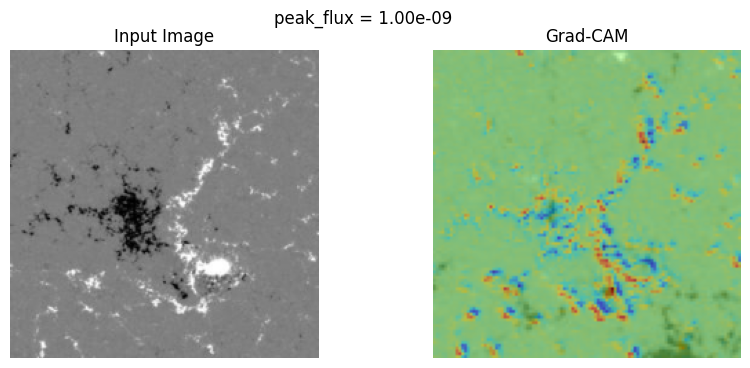

In [450]:
idx = random.randint(0, len(train_single)-1)
print(idx)
show_gradcam(baseline_model, train_single, idx=idx, device=device)

In [ ]:
import math

baseline_model.eval()

baseline_errors = []
samples = []

with torch.no_grad():
    for i in range(len(val_ds2)):
        x, y, _ = val_ds2[i]

        # baseline = SINGLE FRAME ONLY
        x_in = x.unsqueeze(0).to(device).float()
        y_val = float(y)

        pred = baseline_model(x_in).item()

        # safety checks
        if math.isnan(pred) or math.isnan(y_val):
            continue

        err = abs(pred - y_val)

        baseline_errors.append(err)
        samples.append((i, x, y_val, pred))

In [458]:
encoder = BaselineCNN().to(device)
temp_model = AttentionTemporalCNN(encoder).to(device)

temp_model.load_state_dict(torch.load("attention.pth"))
temp_model.eval()

frame_errors = []
samples2 = []

with torch.no_grad():
    for i in range(len(val_ds)):
        x, y, _ = val_ds[i]

        x_in = x.unsqueeze(0).to(device).float()
        y_val = float(y)

        pred, attn = temp_model(x_in)   # FIX HERE
        pred = pred.item()

        if math.isnan(pred) or math.isnan(y_val):
            continue

        err = abs(pred - y_val)

        frame_errors.append(err)
        samples2.append((i, x, y_val, pred, attn))

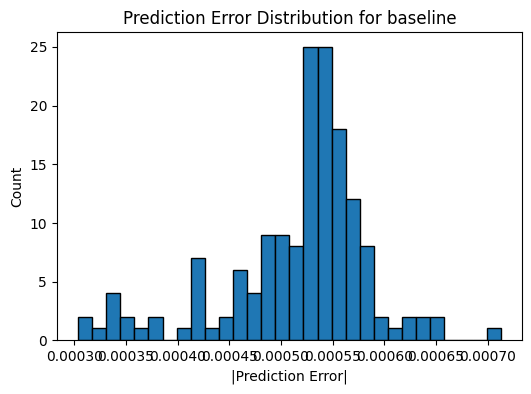

In [457]:
plt.figure(figsize=(6,4))
plt.hist(baseline_errors, bins=30, edgecolor='black')
plt.title("Prediction Error Distribution for baseline")
plt.xlabel("|Prediction Error|")
plt.ylabel("Count")
plt.show()

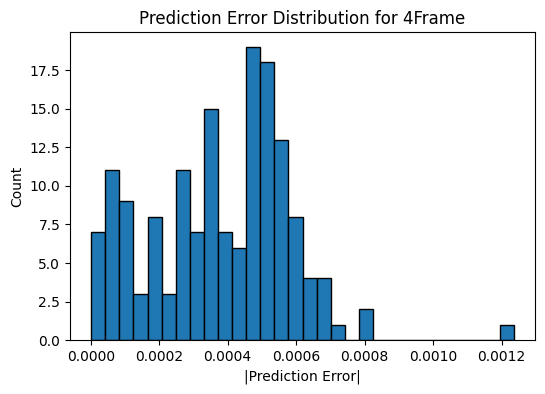

In [459]:
plt.figure(figsize=(6,4))
plt.hist(frame_errors, bins=30, edgecolor='black')
plt.title("Prediction Error Distribution for 4Frame")
plt.xlabel("|Prediction Error|")
plt.ylabel("Count")
plt.show()

In [461]:
def summarize_errors(errors, name):
    errors = np.array(errors)
    
    print(f"\n{name}:")
    print("Mean:", errors.mean())
    print("Std:", errors.std())
    print("Median:", np.median(errors))
    print("90th percentile:", np.percentile(errors, 90))
    print("95th percentile:", np.percentile(errors, 95))
    print("99th percentile:", np.percentile(errors, 99))
    print("Max:", errors.max())


summarize_errors(baseline_errors, "Baseline")
summarize_errors(frame_errors, "4Frame")


Baseline:
Mean: 0.0005163896836932923
Std: 6.945849613848653e-05
Median: 0.0005313168035278037
90th percentile: 0.0005804694013127997
95th percentile: 0.0006034458742866232
99th percentile: 0.0006502895416451793
Max: 0.0007125391380319313

4Frame:
Mean: 0.0003772483950787679
Std: 0.00020494359532951994
Median: 0.0003963420854339317
90th percentile: 0.0005993480549583152
95th percentile: 0.0006429181058613895
99th percentile: 0.000793639553717278
Max: 0.0012359852658042625


Temporal modeling improves typical predictions but introduces some instability in difficult cases. It looks like the distribution for the baseline is taller, which means it is more consistant. Adding the 4 frames helps the overall erorr, but actually introduces some instability/inconsistancy.

However, it looks like the attention does not work (weights) are all the same for all frames.

In [469]:
class FrameDiffModel(nn.Module):
    def __init__(self, base_cnn):
        super().__init__()
        self.cnn = base_cnn

        self.head = nn.Sequential(
            nn.Linear(4 * 2048, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        """
        x: [B, T, C, H, W]  (T=4)
        """
        f1, f2, f3, f4 = x[:, 0], x[:, 1], x[:, 2], x[:, 3]

        # differences
        d1 = f2 - f1
        d2 = f3 - f2
        d3 = f4 - f3

        # extract features (NOT predictions)
        feat_f4 = self.cnn.forward_features(f4)
        feat_d1 = self.cnn.forward_features(d1)
        feat_d2 = self.cnn.forward_features(d2)
        feat_d3 = self.cnn.forward_features(d3)

        feats = torch.cat([feat_f4, feat_d1, feat_d2, feat_d3], dim=1)

        out = self.head(feats).squeeze()
        return out

In [471]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch

# extract only VALID dataset samples
sample_ids = [train_sequence.df.index[i] for i in train_sequence.valid_indices]

# get active region ids
groups = np.array([s.split("_")[0] for s in sample_ids])

# dataset indices (aligned)
indices = np.arange(len(train_sequence))

# group-aware split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
train_idx, val_idx = next(gss.split(indices, groups=groups))

# subsets
train_ds3 = Subset(train_sequence, train_idx)
val_ds3 = Subset(train_sequence, val_idx)

train_loader = DataLoader(train_ds3, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds3, batch_size=8, shuffle=False)

# --- MODEL SETUP ---
base_cnn = BaselineCNN().to(device)
model = FrameDiffModel(base_cnn).to(device)

loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- TRAINING LOOP ---
epochs = 15

for epoch in range(epochs):

    # training
    model.train()
    train_loss = 0

    for x, y, _ in train_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()

        optimizer.zero_grad()

        preds = model(x)           # [B]
        loss = loss_fn(preds, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y, _ in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()

            preds = model(x)
            loss = loss_fn(preds, y)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

Epoch 1/15 | Train: 0.016461 | Val: 0.000690
Epoch 2/15 | Train: 0.003393 | Val: 0.003556
Epoch 3/15 | Train: 0.002736 | Val: 0.004329
Epoch 4/15 | Train: 0.002783 | Val: 0.001019
Epoch 5/15 | Train: 0.002915 | Val: 0.004494
Epoch 6/15 | Train: 0.002358 | Val: 0.001407
Epoch 7/15 | Train: 0.001132 | Val: 0.001953
Epoch 8/15 | Train: 0.003979 | Val: 0.000187
Epoch 9/15 | Train: 0.001512 | Val: 0.000183
Epoch 10/15 | Train: 0.002733 | Val: 0.002218
Epoch 11/15 | Train: 0.001448 | Val: 0.000614
Epoch 12/15 | Train: 0.001897 | Val: 0.004091
Epoch 13/15 | Train: 0.001600 | Val: 0.001742
Epoch 14/15 | Train: 0.001279 | Val: 0.001573
Epoch 15/15 | Train: 0.001278 | Val: 0.000955


In [472]:
torch.save(model.state_dict(), "framediff_model.pth")

In [473]:
test_loss = 0
all_errors = []
preds_list = []
targets_list = []

with torch.no_grad():
    for x, y, _ in val_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()

        preds = model(x)           # [B]

        loss = loss_fn(preds, y)
        test_loss += loss.item()

        # per-sample errors
        errors = torch.abs(preds - y)

        all_errors.extend(errors.cpu().numpy())
        preds_list.extend(preds.cpu().numpy())
        targets_list.extend(y.cpu().numpy())

test_loss /= len(val_loader)

all_errors = np.array(all_errors)
preds_list = np.array(preds_list)
targets_list = np.array(targets_list)

print(f"Final Test Loss (MAE): {test_loss:.6f}")

print("\nError Summary:")
print("Mean:", all_errors.mean())
print("Median:", np.median(all_errors))
print("Std:", all_errors.std())
print("90th:", np.percentile(all_errors, 90))
print("95th:", np.percentile(all_errors, 95))
print("99th:", np.percentile(all_errors, 99))
print("Max:", all_errors.max())

Final Test Loss (MAE): 0.000955

Error Summary:
Mean: 0.0009540809
Median: 0.0009870332
Std: 0.00019719232
90th: 0.0011500787
95th: 0.0011899831
99th: 0.001250725
Max: 0.001284241


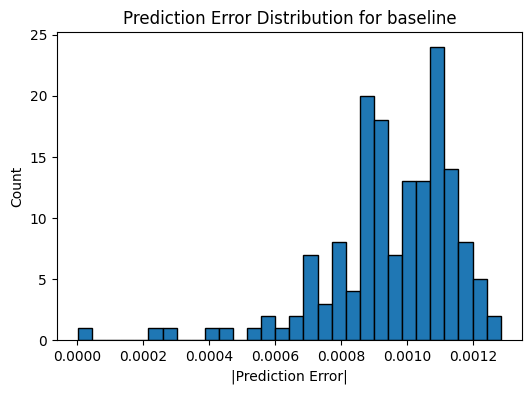

In [478]:
diff_errors = []
samples = []

with torch.no_grad():
    for i in range(len(val_ds)):
        x, y, _ = val_ds[i]

        x_in = x.unsqueeze(0).to(device).float()
        y_val = float(y)

        pred = model(x_in)   # FIX HERE
        pred = pred.item()

        if math.isnan(pred) or math.isnan(y_val):
            continue

        err = abs(pred - y_val)

        diff_errors.append(err)
        samples2.append((i, x, y_val, pred, attn))

plt.figure(figsize=(6,4))
plt.hist(diff_errors, bins=30, edgecolor='black')
plt.title("Prediction Error Distribution for baseline")
plt.xlabel("|Prediction Error|")
plt.ylabel("Count")
plt.show()

In [479]:
summarize_errors(baseline_errors, "Baseline")
summarize_errors(frame_errors, "4Frame")
summarize_errors(diff_errors, "FrameDiff")


Baseline:
Mean: 0.0005163896836932923
Std: 6.945849613848653e-05
Median: 0.0005313168035278037
90th percentile: 0.0005804694013127997
95th percentile: 0.0006034458742866232
99th percentile: 0.0006502895416451793
Max: 0.0007125391380319313

4Frame:
Mean: 0.0003772483950787679
Std: 0.00020494359532951994
Median: 0.0003963420854339317
90th percentile: 0.0005993480549583152
95th percentile: 0.0006429181058613895
99th percentile: 0.000793639553717278
Max: 0.0012359852658042625

FrameDiff:
Mean: 0.0009540806349201371
Std: 0.0001971926937507375
Median: 0.0009870332910290047
90th percentile: 0.0011500787840241556
95th percentile: 0.0011899830114089126
99th percentile: 0.0012507249970563005
Max: 0.0012842409555560153


In [480]:
def entropy(weights):
    return -(weights * torch.log(weights + 1e-8)).sum(dim=1).mean()

entropy(all_attn)

tensor(1.3863)